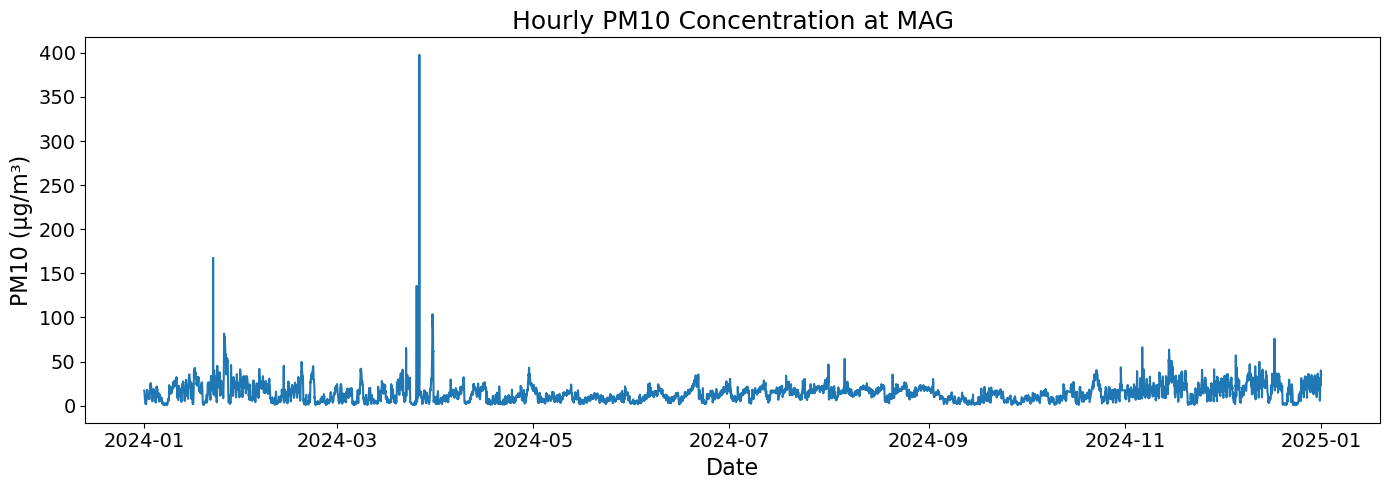

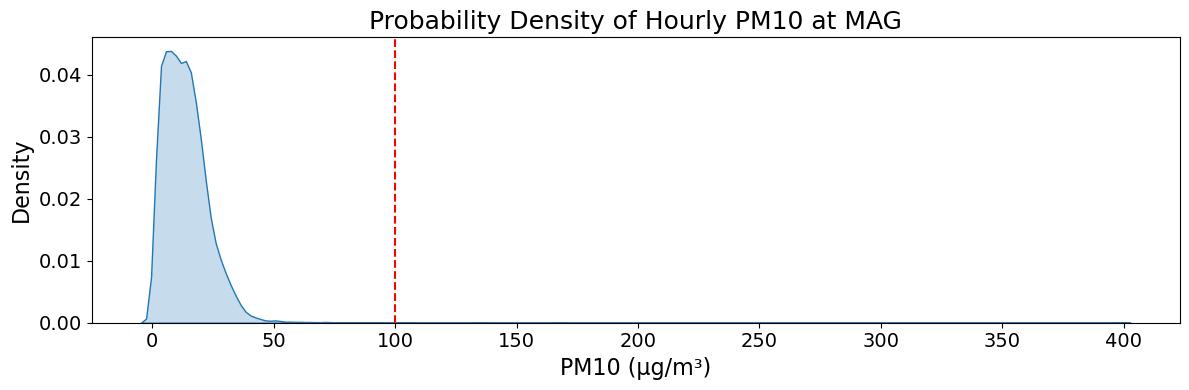

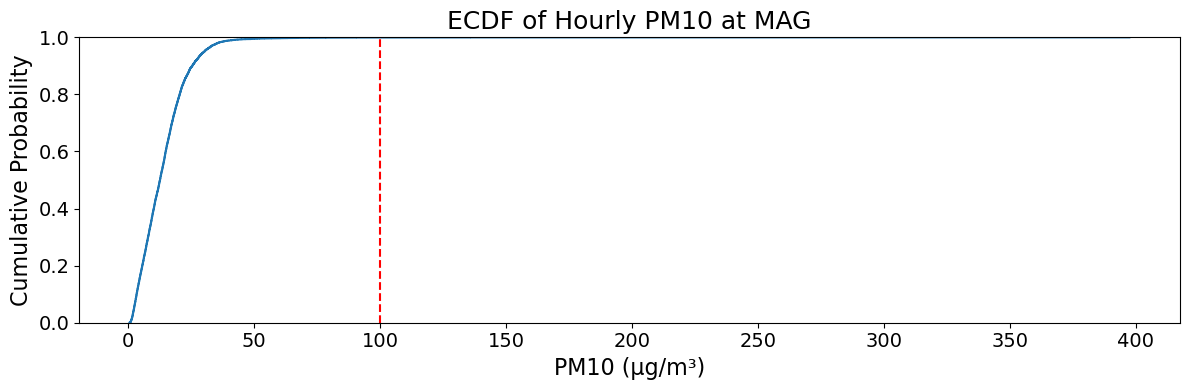


Extreme hourly PM10 values at MAG (>100 µg/m³):
                 datetime        date  hour  day  month   PM10
514  2024-01-22 11:00:00  2024-01-22    11   22      1  167.5
2033 2024-03-25 18:00:00  2024-03-25    18   25      3  135.8
2053 2024-03-26 14:00:00  2024-03-26    14   26      3  397.7
2151 2024-03-30 16:00:00  2024-03-30    16   30      3  103.7


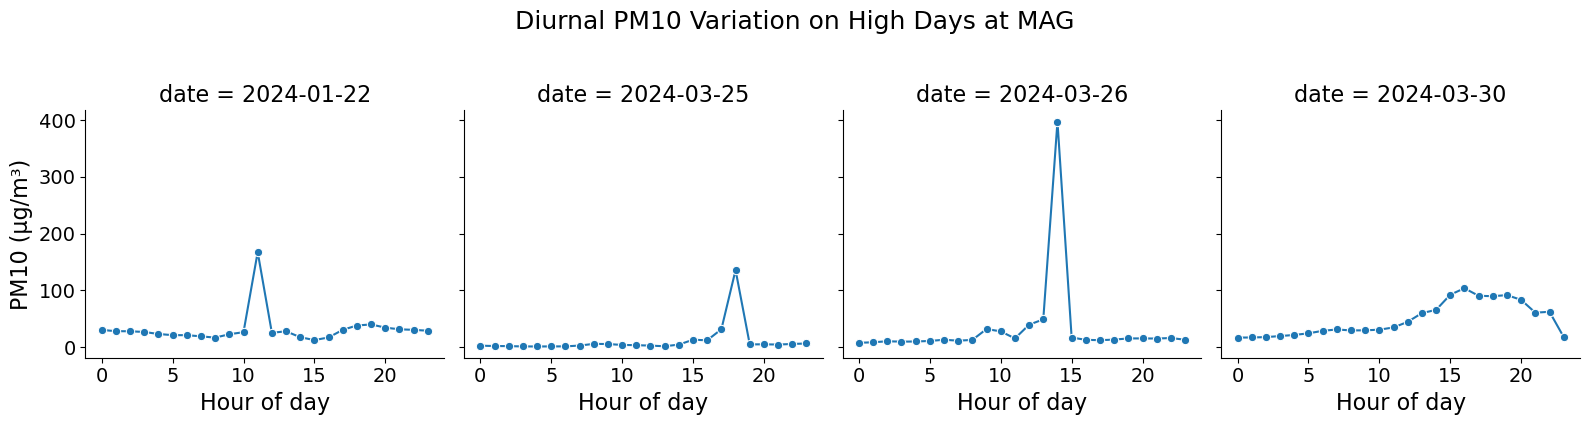


Mean daily PM10 on high days:
date
2024-01-22    31.733333
2024-03-25    10.687500
2024-03-26    32.591667
2024-03-30    48.362500
Name: PM10, dtype: float64

Trimmed mean daily PM10 (10% trim):
date
2024-01-22    26.265
2024-03-25     4.360
2024-03-26    15.990
2024-03-30    46.560
Name: PM10, dtype: float64


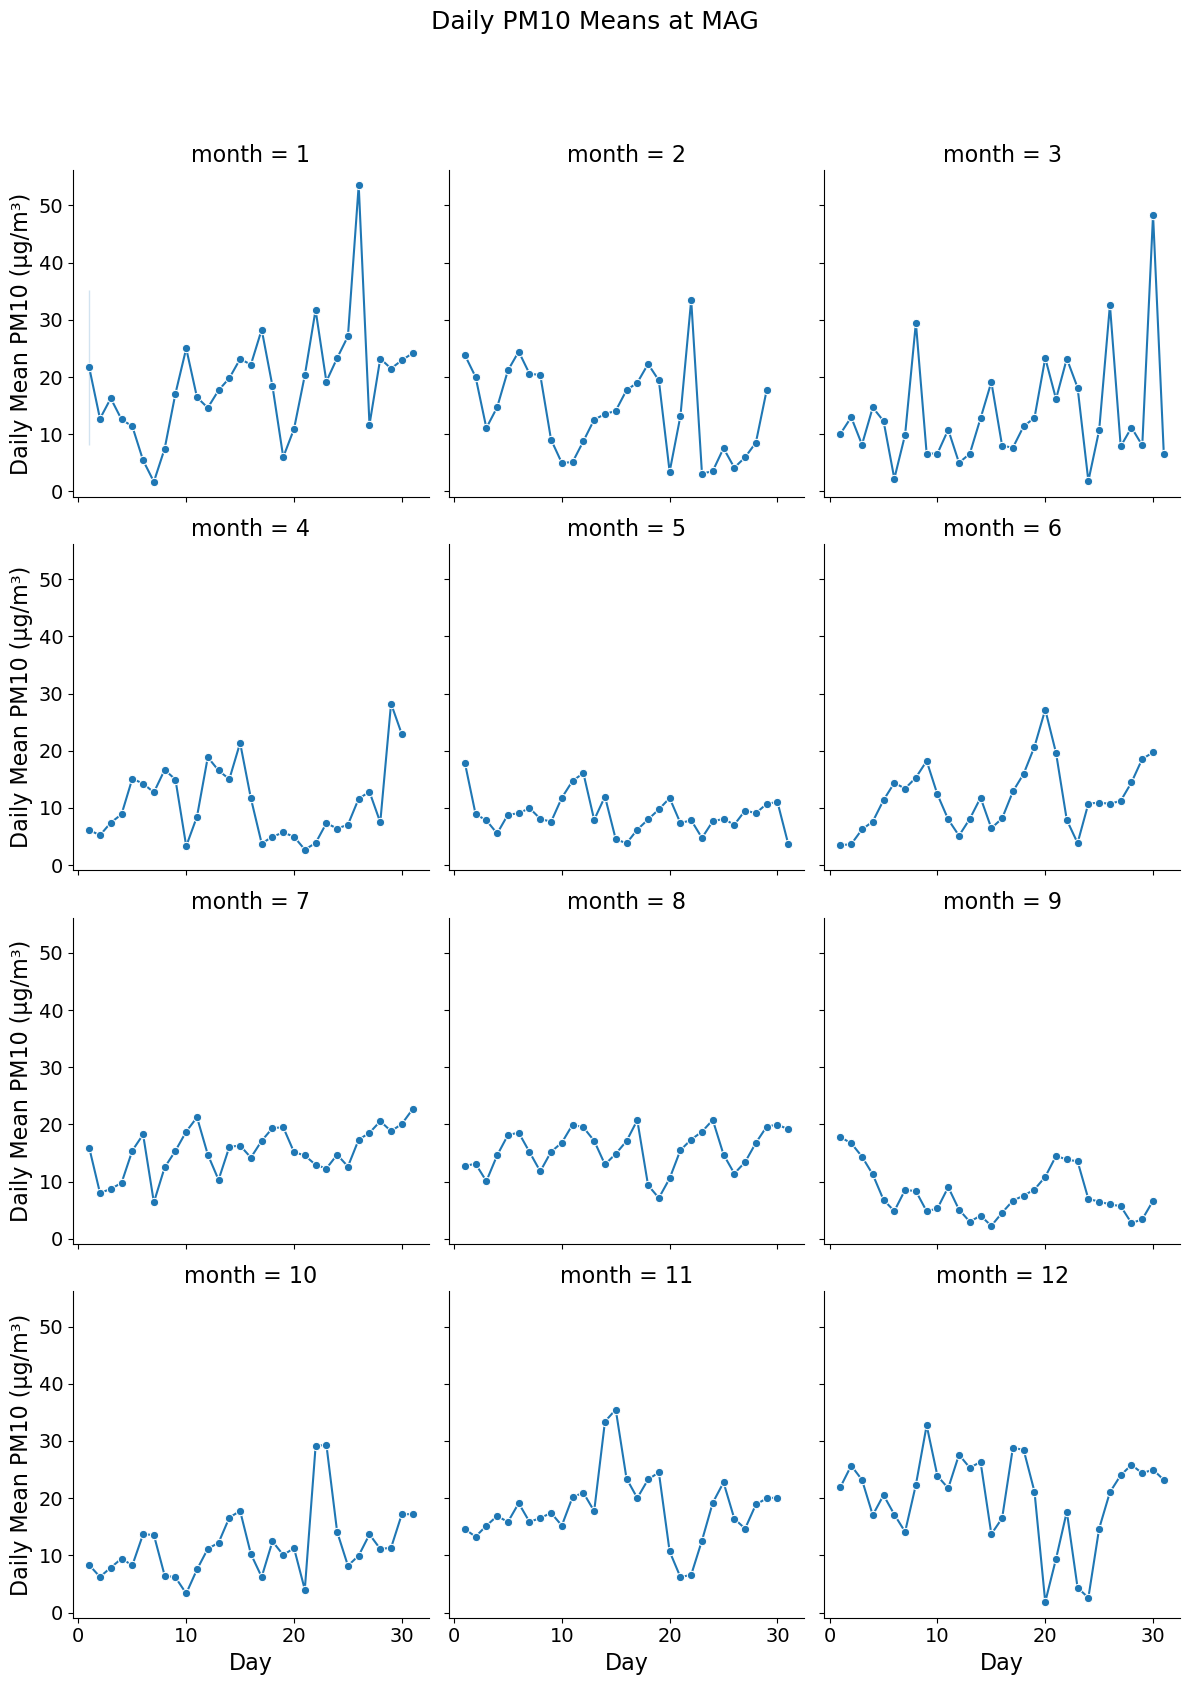

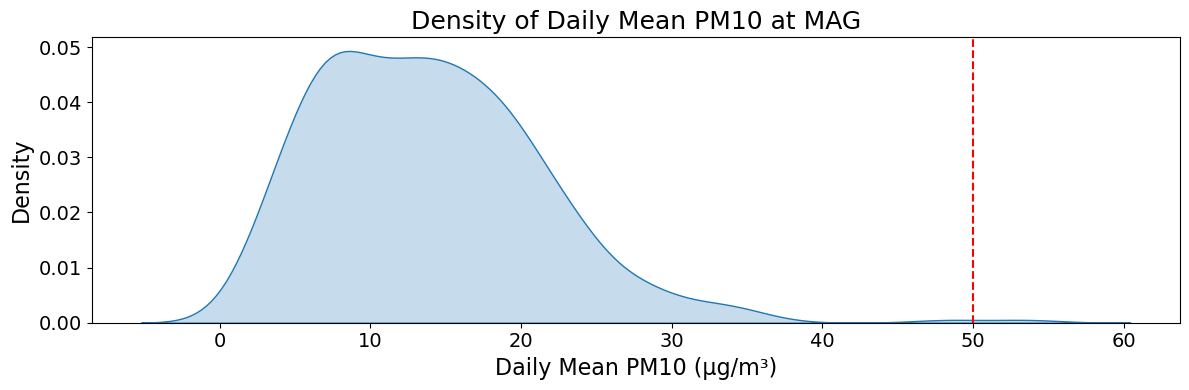

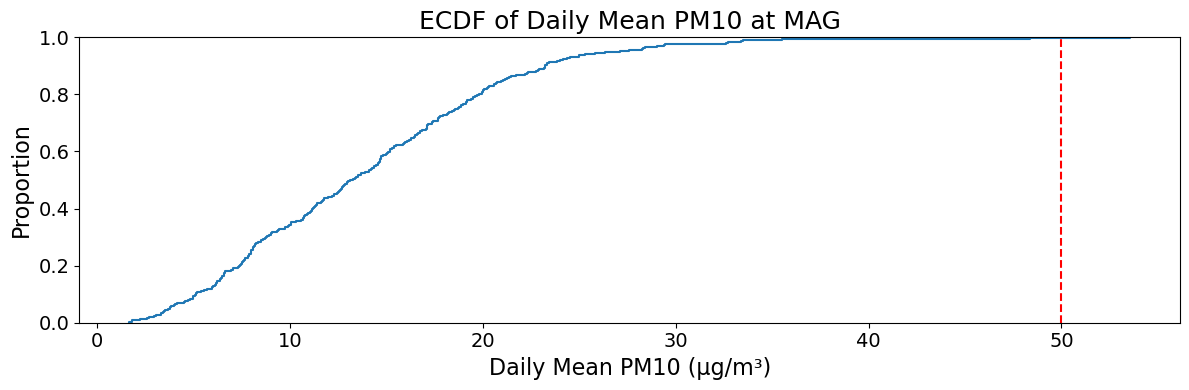


Days with daily mean PM10 > 50 µg/m³ at MAG:
           date   PM10  day  month
25  2024-01-26  53.55   26      1


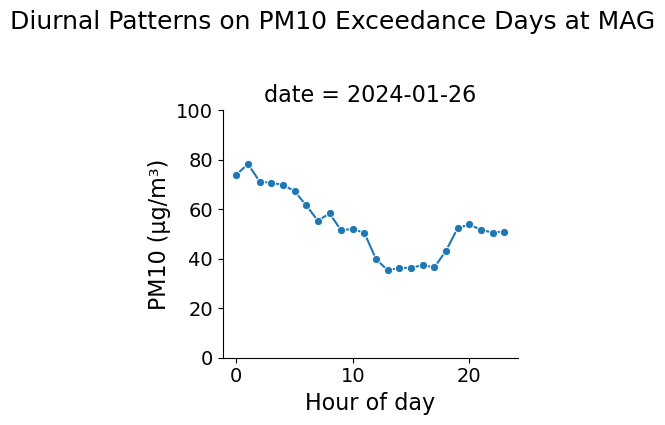

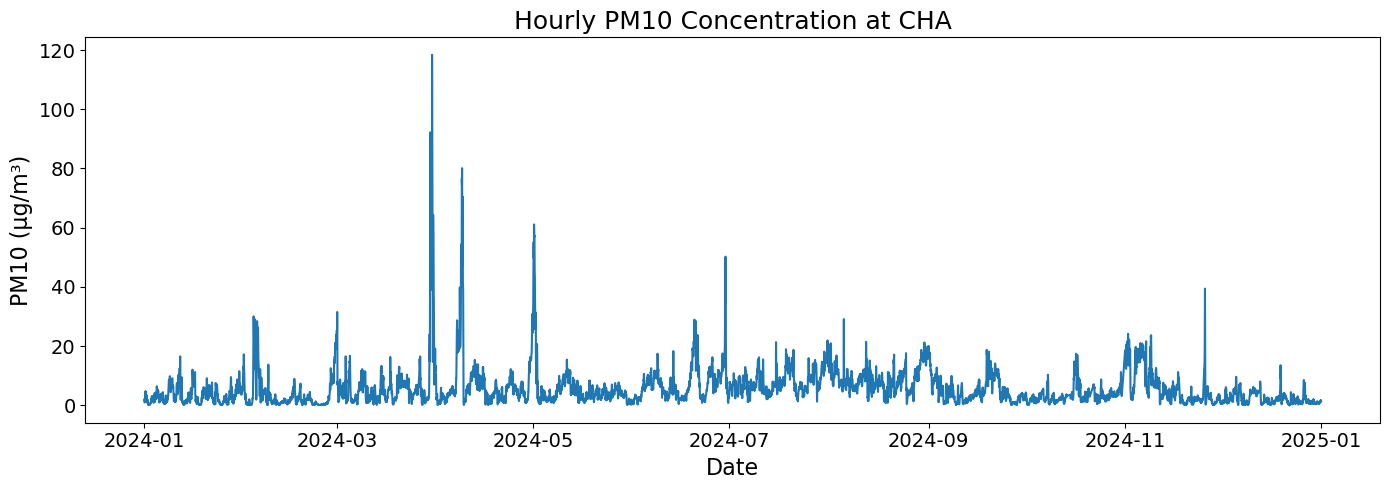

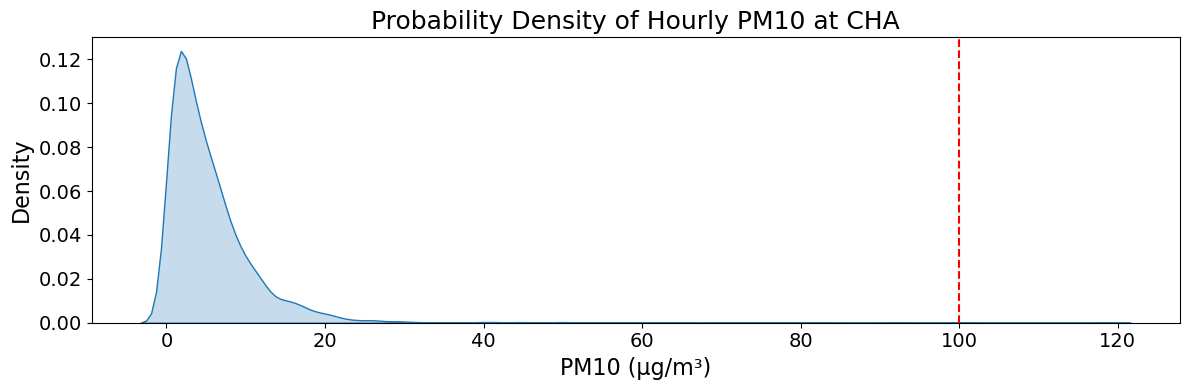

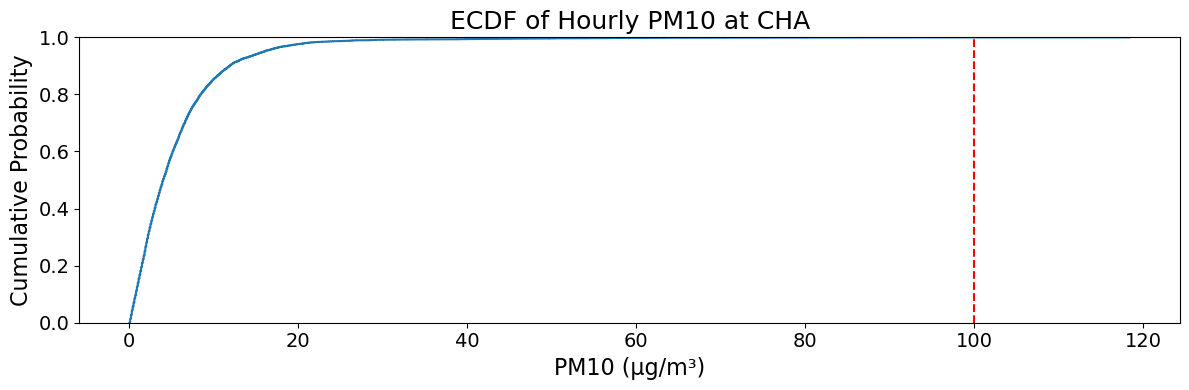


Extreme hourly PM10 values at CHA (>100 µg/m³):
                 datetime        date  hour  day  month   PM10
2148 2024-03-30 13:00:00  2024-03-30    13   30      3  118.4
2149 2024-03-30 14:00:00  2024-03-30    14   30      3  100.3


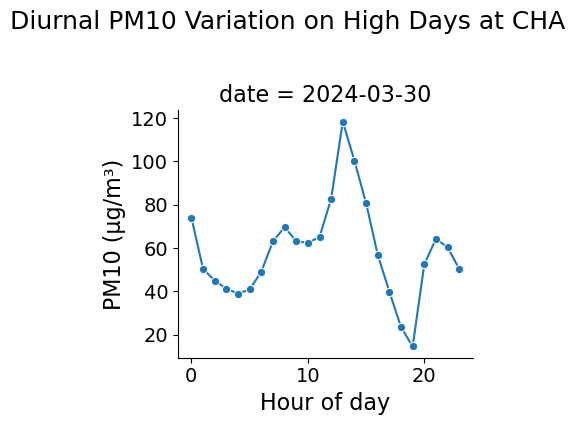


Mean daily PM10 on high days:
date
2024-03-30    58.666667
Name: PM10, dtype: float64

Trimmed mean daily PM10 (10% trim):
date
2024-03-30    57.56
Name: PM10, dtype: float64


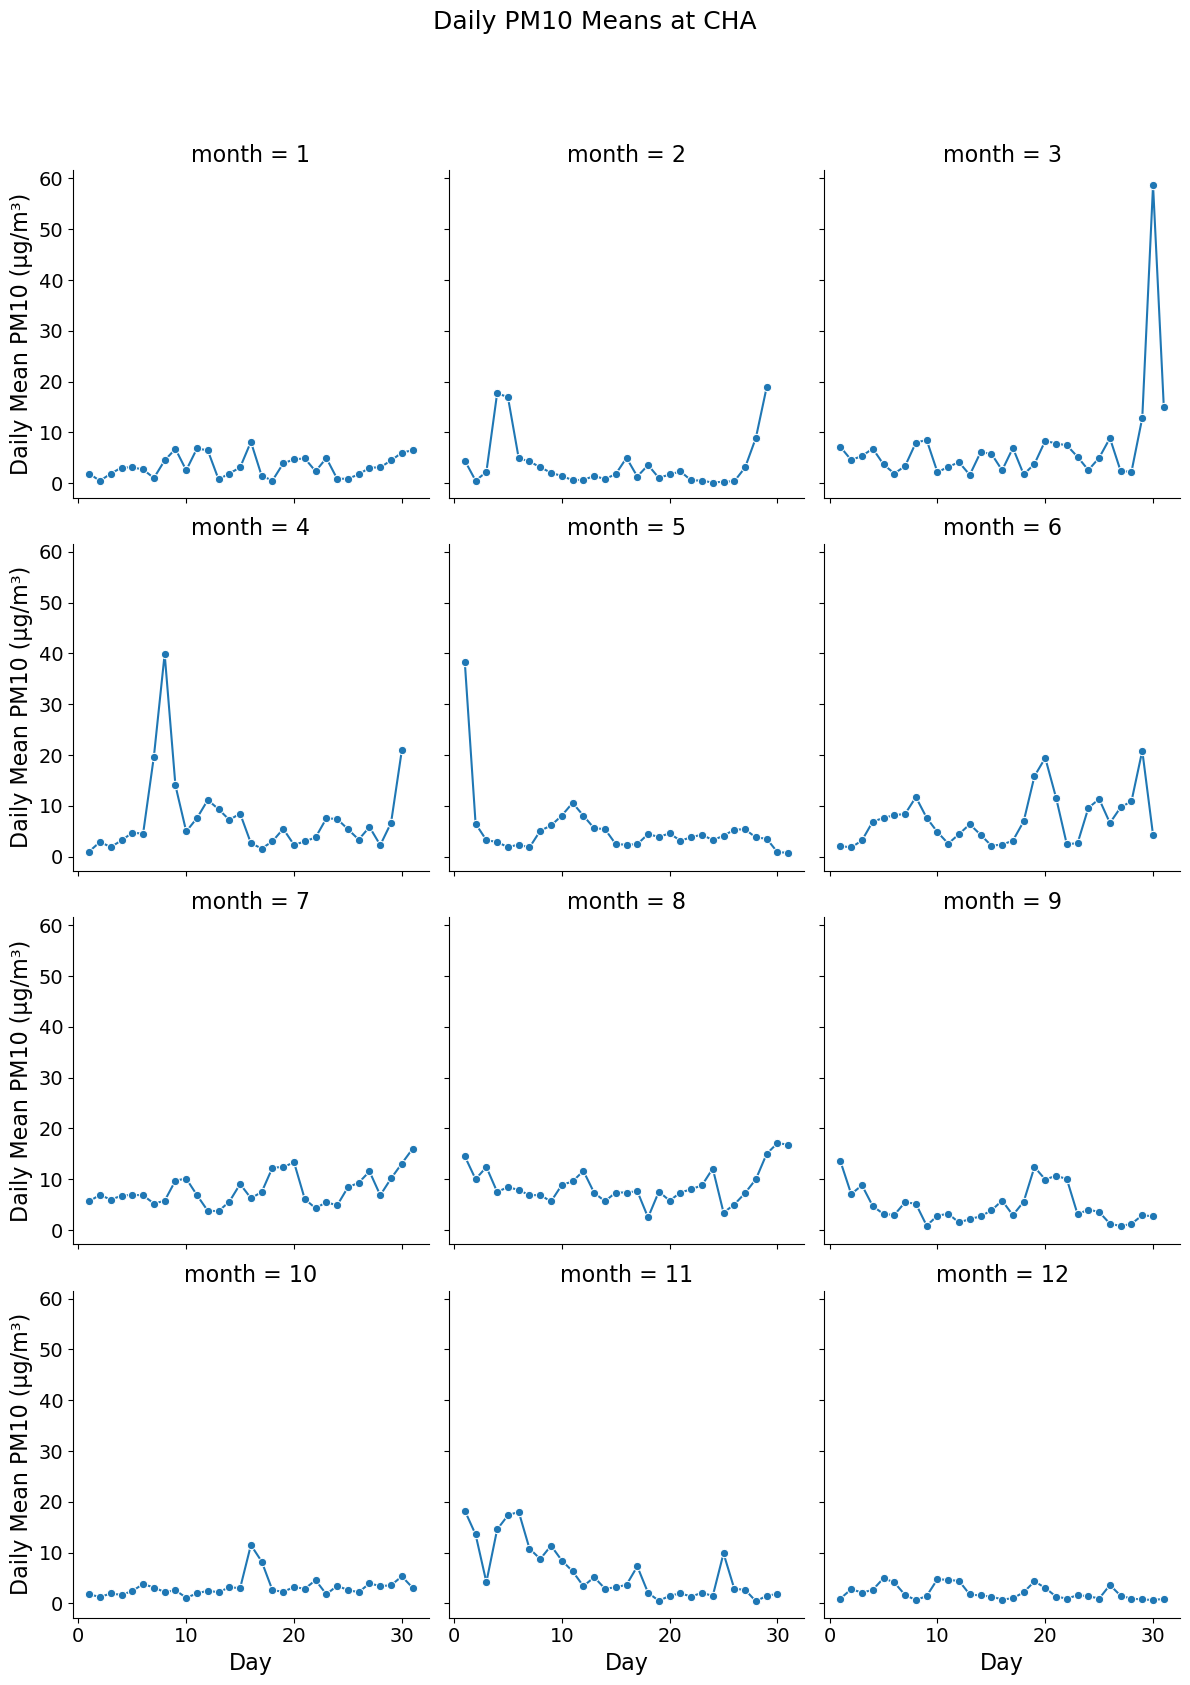

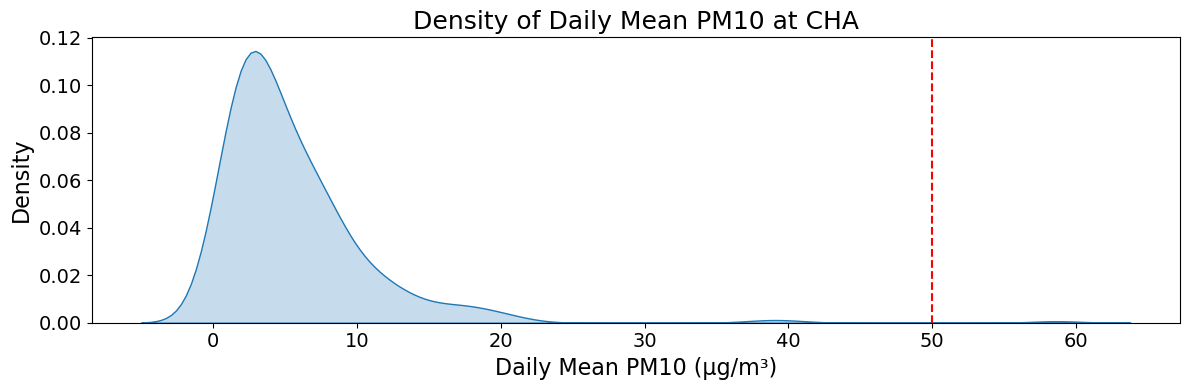

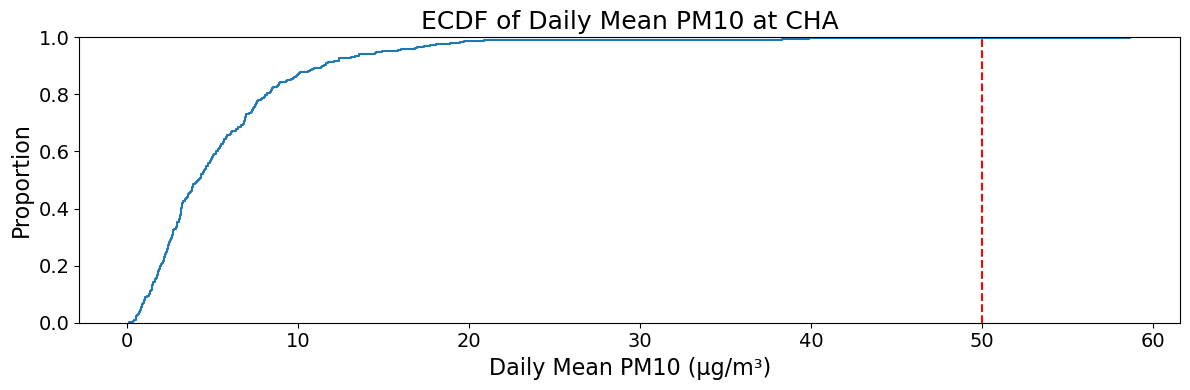


Days with daily mean PM10 > 50 µg/m³ at CHA:
           date       PM10  day  month
89  2024-03-30  58.666667   30      3


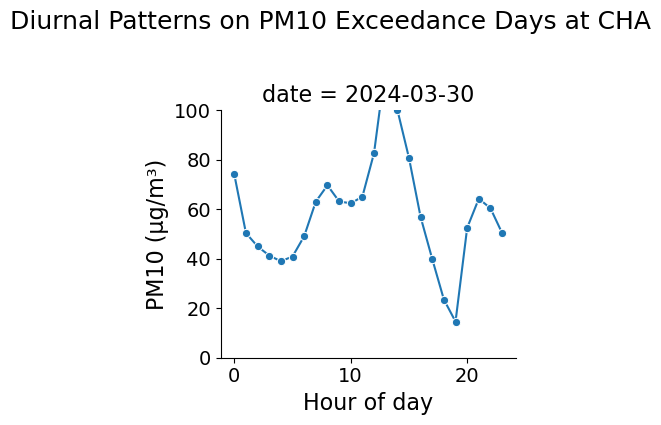

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter

plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.titlesize': 18
})

# Load and clean data
df = pd.read_csv('DATA.csv', sep=';', decimal=',', parse_dates=['TIME'], dayfirst=True)
df = df.rename(columns={'TIME': 'datetime'})
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

# Define function to plot all charts for one station
def plot_pm10_analysis(station_code):
    col = f'PM10{station_code}'
    df_station = df[['datetime', 'date', 'hour', 'day', 'month', col]].copy()
    df_station = df_station.rename(columns={col: 'PM10'})
    df_station = df_station.dropna()

    # Time series: hourly
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=df_station, x='datetime', y='PM10')
    plt.title(f'Hourly PM10 Concentration at {station_code}')
    plt.xlabel('Date')
    plt.ylabel('PM10 (µg/m³)')
    plt.tight_layout()
    plt.show()

    # Density and ECDF
    plt.figure(figsize=(12, 4))
    sns.kdeplot(df_station['PM10'], fill=True)
    plt.axvline(100, color='red', linestyle='--', label='Limit')
    plt.title(f'Probability Density of Hourly PM10 at {station_code}')
    plt.xlabel('PM10 (µg/m³)')
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    sns.ecdfplot(df_station['PM10'])
    plt.axvline(100, color='red', linestyle='--', label='Limit')
    plt.title(f'ECDF of Hourly PM10 at {station_code}')
    plt.xlabel('PM10 (µg/m³)')
    plt.ylabel('Cumulative Probability')
    plt.tight_layout()
    plt.show()

    # Extreme hourly values > 100
    extreme_hourly = df_station[df_station['PM10'] > 100]
    print(f"\nExtreme hourly PM10 values at {station_code} (>100 µg/m³):\n", extreme_hourly)

    # Diurnal variation on those dates
    high_dates = extreme_hourly['date'].unique()
    highdays = df_station[df_station['date'].isin(high_dates)]
    number_of_highdays = len(highdays['date'].unique())

    if not highdays.empty:
        g = sns.FacetGrid(highdays, col='date', col_wrap=number_of_highdays, height=4)
        g.map_dataframe(sns.lineplot, x='hour', y='PM10', marker='o')
        g.set_axis_labels("Hour of day", "PM10 (µg/m³)")
        g.fig.suptitle(f'Diurnal PM10 Variation on High Days at {station_code}', y=1.05)
        plt.tight_layout()
        plt.show()

        # Mean and trimmed mean
        print("\nMean daily PM10 on high days:")
        print(highdays.groupby('date')['PM10'].mean())

        print("\nTrimmed mean daily PM10 (10% trim):")
        from scipy.stats import trim_mean
        print(highdays.groupby('date')['PM10'].apply(lambda x: trim_mean(x, proportiontocut=0.1)))

    # Daily means
    daily = df_station.groupby('date')['PM10'].mean().reset_index()
    daily['day'] = pd.to_datetime(daily['date']).dt.day
    daily['month'] = pd.to_datetime(daily['date']).dt.month

    # Time series of daily means
    g = sns.FacetGrid(daily, col='month', col_wrap=3, height=4)
    g.map_dataframe(sns.lineplot, x='day', y='PM10', marker='o')
    g.set_axis_labels("Day", "Daily Mean PM10 (µg/m³)")
    g.fig.suptitle(f'Daily PM10 Means at {station_code}', y=1.05)
    plt.tight_layout()
    plt.show()

    # Density & ECDF of daily means
    plt.figure(figsize=(12, 4))
    sns.kdeplot(daily['PM10'], fill=True)
    plt.axvline(x=50, linestyle='--', color='red')
    plt.title(f'Density of Daily Mean PM10 at {station_code}')
    plt.xlabel('Daily Mean PM10 (µg/m³)')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    sns.ecdfplot(daily['PM10'])
    plt.axvline(x=50, linestyle='--', color='red')
    plt.title(f'ECDF of Daily Mean PM10 at {station_code}')
    plt.xlabel('Daily Mean PM10 (µg/m³)')
    plt.tight_layout()
    plt.show()

    # Days exceeding threshold
    exceeded = daily[daily['PM10'] > 50]
    print(f"\nDays with daily mean PM10 > 50 µg/m³ at {station_code}:\n", exceeded)

    exceed_hours = df_station[df_station['date'].isin(exceeded['date'])]
    number_of_exceed_hours = len(exceed_hours['date'].unique())
    if not exceed_hours.empty:
        g = sns.FacetGrid(exceed_hours, col='date', col_wrap=number_of_exceed_hours, height=4)
        g.map_dataframe(sns.lineplot, x='hour', y='PM10', marker='o')
        g.set_axis_labels("Hour of day", "PM10 (µg/m³)")
        g.set(ylim=(0, 100))
        g.fig.suptitle(f'Diurnal Patterns on PM10 Exceedance Days at {station_code}', y=1.05)
        plt.tight_layout()
        plt.show()

# Run for both stations
plot_pm10_analysis('MAG')
plot_pm10_analysis('CHA')
